In [1]:
## Imports

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
## Dataframe
df = pd.read_csv('./data/DataCleaning.csv')

In [3]:
## View 

df

,Duration,Date,Pulse,Maxpulse,Calories
0,60,2023/12/01',110,130,409.1
1,60,2023/12/02',117,145,479.0
2,60,2023/12/03',103,135,340.0
3,45,2023/12/04',109,175,282.4
4,45,2023/12/05',117,148,406.0
5,60,2023/12/06',102,127,300.0
6,60,2023/12/07',110,136,374.0
7,450,2023/12/08',104,134,253.3
8,30,2023/12/09',109,133,195.1
9,60,2023/12/10',98,124,269.0


In [4]:
## Handling the missing values

#---- Me going first for the mean of Calories Column ----#
mean_calories = df['Calories'].mean()

## If found NaN in Calories column, replace it with mean_calories
df['Calories'] = df['Calories'].fillna(mean_calories)

In [5]:
df


,Duration,Date,Pulse,Maxpulse,Calories
0,60,2023/12/01',110,130,409.10
1,60,2023/12/02',117,145,479.00
2,60,2023/12/03',103,135,340.00
3,45,2023/12/04',109,175,282.40
4,45,2023/12/05',117,148,406.00
5,60,2023/12/06',102,127,300.00
6,60,2023/12/07',110,136,374.00
7,450,2023/12/08',104,134,253.30
8,30,2023/12/09',109,133,195.10
9,60,2023/12/10',98,124,269.00


In [6]:
## There still exists NaN in Date Column. Let's drop the rows with NaN in Date column
df = df.dropna(subset=['Date'])

In [7]:
df

,Duration,Date,Pulse,Maxpulse,Calories
0,60,2023/12/01',110,130,409.10
1,60,2023/12/02',117,145,479.00
2,60,2023/12/03',103,135,340.00
3,45,2023/12/04',109,175,282.40
4,45,2023/12/05',117,148,406.00
5,60,2023/12/06',102,127,300.00
6,60,2023/12/07',110,136,374.00
7,450,2023/12/08',104,134,253.30
8,30,2023/12/09',109,133,195.10
9,60,2023/12/10',98,124,269.00


In [8]:
## In the date column: I see a row that has invalid date format
## In the date column: I see a row that has invalid date format
# first run the normal parser (it will happily convert “2023‑12‑01” etc.)
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# if you also get compact numbers like 20231226, parse them with the
# corresponding format (or re‑parse the NaT values)
mask = df['Date'].isna()
df.loc[mask, 'Date'] = pd.to_datetime(
    df.loc[mask, 'Date'],
    format='%Y%m%d',
    errors='coerce'
)

df

,Duration,Date,Pulse,Maxpulse,Calories
0,60,2023-12-01,110,130,409.10
1,60,2023-12-02,117,145,479.00
2,60,2023-12-03,103,135,340.00
3,45,2023-12-04,109,175,282.40
4,45,2023-12-05,117,148,406.00
5,60,2023-12-06,102,127,300.00
6,60,2023-12-07,110,136,374.00
7,450,2023-12-08,104,134,253.30
8,30,2023-12-09,109,133,195.10
9,60,2023-12-10,98,124,269.00


In [10]:
## Anywayyy.. there is still a NaT in the Date column. Let's drop that row as well
df = df.dropna(subset=['Date'])
df

,Duration,Date,Pulse,Maxpulse,Calories
0,60,2023-12-01,110,130,409.10
1,60,2023-12-02,117,145,479.00
2,60,2023-12-03,103,135,340.00
3,45,2023-12-04,109,175,282.40
4,45,2023-12-05,117,148,406.00
5,60,2023-12-06,102,127,300.00
6,60,2023-12-07,110,136,374.00
7,450,2023-12-08,104,134,253.30
8,30,2023-12-09,109,133,195.10
9,60,2023-12-10,98,124,269.00


In [11]:
## In duration column I can see a exception value: thresholding to 100 max
df['Duration'] = df['Duration'].clip(upper=100)
df

,Duration,Date,Pulse,Maxpulse,Calories
0,60,2023-12-01,110,130,409.10
1,60,2023-12-02,117,145,479.00
2,60,2023-12-03,103,135,340.00
3,45,2023-12-04,109,175,282.40
4,45,2023-12-05,117,148,406.00
5,60,2023-12-06,102,127,300.00
6,60,2023-12-07,110,136,374.00
7,100,2023-12-08,104,134,253.30
8,30,2023-12-09,109,133,195.10
9,60,2023-12-10,98,124,269.00


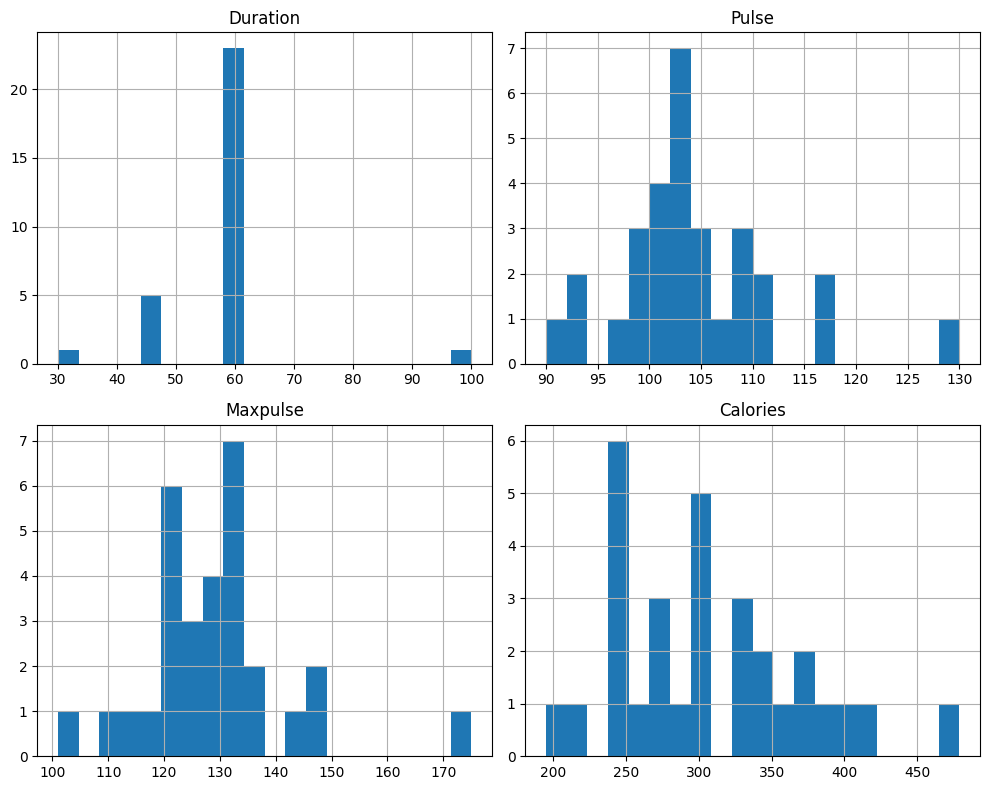

In [13]:
## Visualize the distribution finally 
df[['Duration', 'Pulse', 'Maxpulse', 'Calories']].hist(bins=20, figsize=(10, 8))
plt.tight_layout()